In [15]:
import numpy as np

#Exercicio 1

M = 1000
lamb = 1.5

#Gerando exponencial pelo metodo da inversao

exponencial_inversao = []
for i in range(M):
    u = np.random.uniform(0,1)
    x = -np.log(u) / lamb
    exponencial_inversao.append(x)

#Gerando exponencial com o numpy

exponencial_numpy = np.random.exponential(1/lamb, size=M)


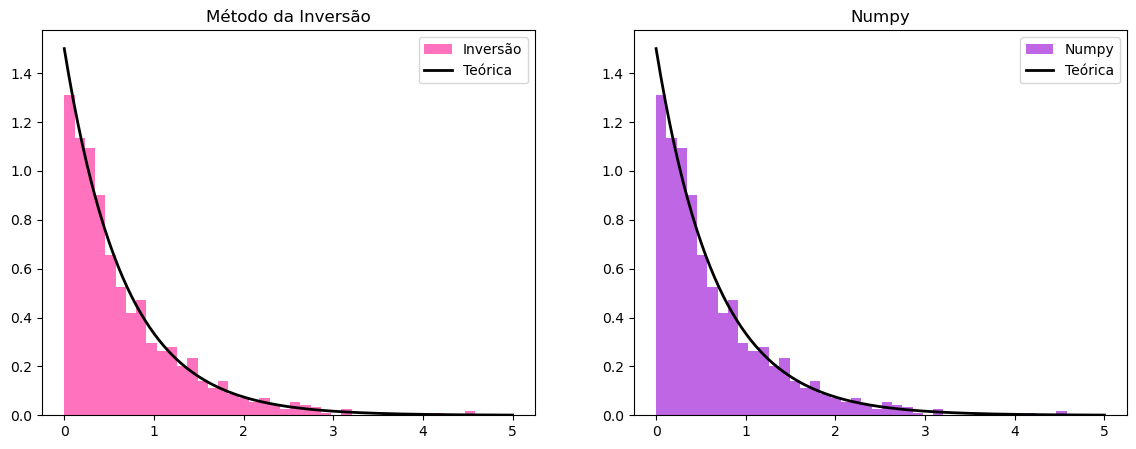

In [16]:
#Histogramas

import matplotlib.pyplot as plt

fig, eixo = plt.subplots(1, 2, figsize=(14, 5))

x_teorico = np.linspace(0, 5, 200)
y_teorico = lamb * np.exp(-lamb * x_teorico)

eixo[0].hist(exponencial_inversao, bins=40, density=True, alpha=0.6, 
             color='deeppink', label='Inversão')
eixo[0].plot(x_teorico, y_teorico, color='black', linewidth=2, label='Teórica')
eixo[0].set_title("Método da Inversão")
eixo[0].legend()


eixo[1].hist(exponencial_inversao, bins=40, density=True, alpha=0.6, 
             color='darkviolet', label='Numpy')
eixo[1].plot(x_teorico, y_teorico, color='black', linewidth=2, label='Teórica')
eixo[1].set_title("Numpy")
eixo[1].legend()
    
plt.show()

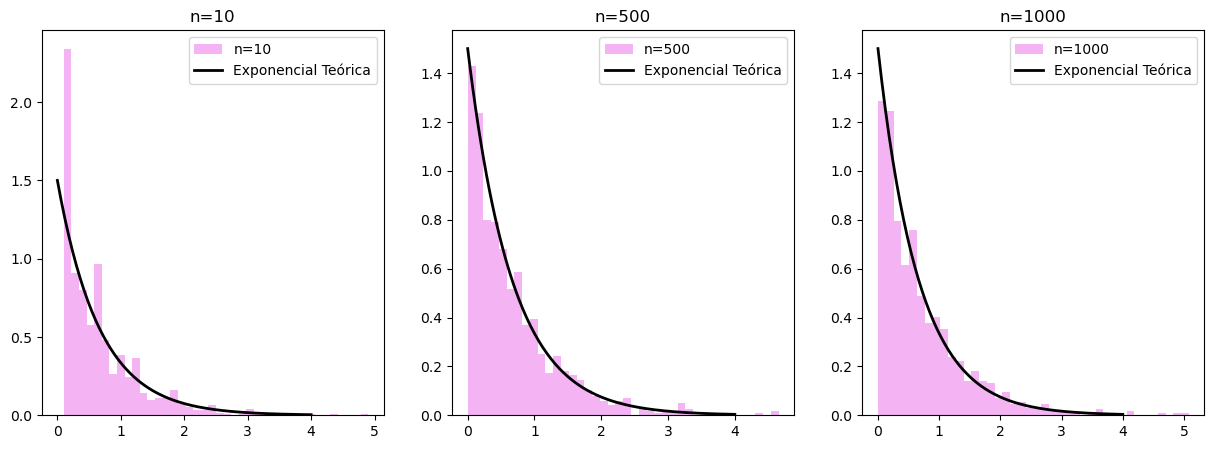

In [19]:
#Exercicio 2

M = 1000
lamb = 1.5

valores_n = [10, 500, 1000]

fig, eixo = plt.subplots(1, 3, figsize=(15, 5))

x_teorico = np.linspace(0, 4, 200)
y_teorico = lamb * np.exp(-lamb * x_teorico)

for i in range(len(valores_n)):
    n = valores_n[i]
    p = lamb / n

    Tn_amostra = []
    for j in range(M):
        Xn = np.random.geometric(p)
        Tn = Xn / n
        Tn_amostra.append(Tn)

#2. histogarama

    eixo[i].hist(Tn_amostra, bins=40, density=True, alpha=0.6, 
             color='violet', label=f'n={n}')
    eixo[i].plot(x_teorico, y_teorico, color='black', linewidth=2, label='Exponencial Teórica')
    eixo[i].set_title(f"n={n}")
    eixo[i].legend()

plt.show()
        

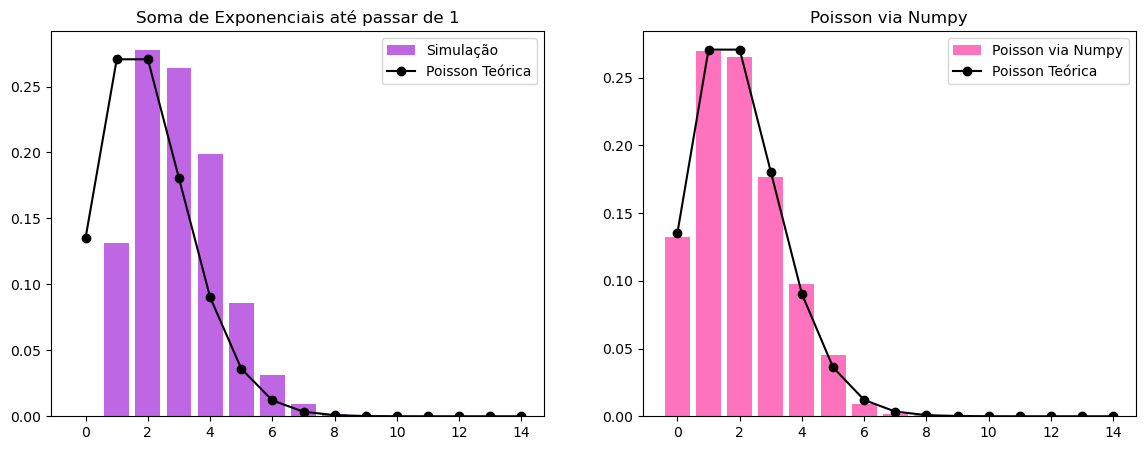

In [25]:
#exercicio 3

import math

M = 1000
lamb = 2.0

#somando variaveis até a somar ultrapassar 1
contagens = []
for i in range(M):
    soma = 0
    contador = 0
    while soma <= 1:
        x = np.random.exponential(1/lamb)
        soma = soma + x
        contador = contador +1

    contagens.append(contador)

#Poisson via numpy
poisson_numpy = np.random.poisson(lamb, size=M)

#histograma

fig, eixo = plt.subplots(1, 2, figsize=(14, 5))

valores_k = range(0, 15)
probabilidade_teorica = []

for k in valores_k:
    probabilidade = (lamb**k * math.exp(-lamb)) / math.factorial(k)
    probabilidade_teorica.append(probabilidade)

eixo[0].hist(contagens, bins=range(0, 15), density=True, alpha=0.6, 
             color='darkviolet', align='left', rwidth=0.8, label='Simulação')
eixo[0].plot(valores_k, probabilidade_teorica, 'o-', label='Poisson Teórica', color='black')
eixo[0].set_title("Soma de Exponenciais até passar de 1")
eixo[0].legend()


eixo[1].hist(poisson_numpy, bins=range(0, 15), density=True, alpha=0.6, 
             color='deeppink', align='left', rwidth=0.8, label='Poisson via Numpy')
eixo[1].plot(valores_k, probabilidade_teorica, 'o-', label='Poisson Teórica', color='black')
eixo[1].set_title("Poisson via Numpy")
eixo[1].legend()

plt.show()